# Dengue past data — outcomes and covariates at any hierarchy level

Rolls the FHS-grain past inputs (473 most-detailed locations × 2000–2023 × 25 age groups
× 2 sexes, complete, zeros kept) up to whatever locations you name — countries, regions,
super-regions, global — all-age or for specific age/sex cells.

**All aggregation is done by `lib/processing/aggregation.py`; nothing is reimplemented here.**

| what | function |
|---|---|
| counts summed into every ancestor, rates rebuilt from that level's OWN population | `aggregate_outcomes_to_ancestors` |
| covariates population-weighted into every ancestor | `roll_up_covariates_to_ancestors` |
| the line painter | `lib.viz.lines.timeseries_panel` |

**The rule that makes aggregate rates right.** An aggregate rate is its summed count
divided by *that level's own population row*, never by the sum of its children's
populations. A parent's population includes people no leaf contributed a count for — for
Global the FHS leaves cover 99.923% of the stored population, so a summed-children
denominator inflates the global rate by ~0.077%, and by more wherever FHS coverage is
patchier. `aggregate_outcomes_to_ancestors` enforces this; the sanity checks at the
bottom show the size of the difference on real data.

Covariates are location-year attributes, identical across all 50 age/sex cells, so they
are weighted by each leaf's **all-age** population and are unaffected by an age/sex
selection.

In [6]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from idd_forecast_mbp import constants as mbpc
from idd_forecast_mbp.lib.data.hierarchy import load_hierarchy
from idd_forecast_mbp.lib.io.parquet import read_parquet_with_integer_ids
from idd_forecast_mbp.lib.processing.aggregation import (
    aggregate_outcomes_to_ancestors,
    roll_up_covariates_to_ancestors,
)
from idd_forecast_mbp.lib.viz.lines import timeseries_panel

RATE_PER = 100_000   # rates are per-capita on disk; dengue rates are small

hierarchy = load_hierarchy()
leaves = read_parquet_with_integer_ids(
    Path(mbpc.DEN_PAST_INPUTS_READ_PATH) / "dengue_past_inputs.parquet")

# 06b stores rates + population only; counts are rate x population by construction.
leaves["dengue_inc_count"] = leaves["dengue_inc_rate"] * leaves["population"]
leaves["dengue_mort_count"] = leaves["dengue_mort_rate"] * leaves["population"]

# Population at EVERY level -- the aggregate denominators. All-age and age/sex.
aa_population = read_parquet_with_integer_ids(
    mbpc.POPULATION_READ_PATH / "aa_2023_full_population_df.parquet",
    columns=["location_id", "year_id", "population"])
as_population = read_parquet_with_integer_ids(
    mbpc.POPULATION_READ_PATH / "as_2023_full_population_df.parquet",
    columns=["location_id", "year_id", "age_group_id", "sex_id", "population"])

COUNT_TO_RATE = {"dengue_inc_count": "dengue_inc_rate",
                 "dengue_mort_count": "dengue_mort_rate"}
KEYS = ["location_id", "year_id", "age_group_id", "sex_id"]
NON_COVARIATE = {*KEYS, *COUNT_TO_RATE, *COUNT_TO_RATE.values(), "population",
                 "A0_location_id", "region_location_id", "super_region_location_id",
                 "level", "most_detailed_lsae", "most_detailed_fhs",
                 "most_detailed_gbd", "fit_eligible"}
COVARIATES = [c for c in leaves.columns if c not in NON_COVARIATE]
LOCATION_NAME = hierarchy.set_index("location_id")["location_name"]

print(f"{len(leaves):,} leaf rows | {leaves.location_id.nunique()} locations | "
      f"{leaves.year_id.min()}-{leaves.year_id.max()} | {len(COVARIATES)} covariates")

567,600 leaf rows | 473 locations | 2000-2023 | 17 covariates


## Aggregate once, reuse

Three frames, each one lib call. All 513 nodes the 473 leaves reach (the leaves plus the
40 aggregates above them) appear in each.

In [7]:
LEAF_COUNTS = leaves[[*KEYS, *COUNT_TO_RATE]]

# All-age: counts summed over age/sex AND up the hierarchy; rates from own aa population.
AA = aggregate_outcomes_to_ancestors(
    LEAF_COUNTS, hierarchy, COUNT_TO_RATE, aa_population)

# Age/sex preserved: same roll-up, rates from own age/sex population per cell.
AS = aggregate_outcomes_to_ancestors(
    LEAF_COUNTS, hierarchy, COUNT_TO_RATE, as_population, preserve_age_sex=True)

# Covariates: population-weighted means, weighted by each leaf's all-age population.
COV = roll_up_covariates_to_ancestors(
    leaves[["location_id", "year_id", *COVARIATES]], hierarchy, COVARIATES, aa_population)

for name, df in [("AA", AA), ("AS", AS), ("COV", COV)]:
    print(f"{name:4s} {len(df):>9,} rows | {df.location_id.nunique()} locations")

AA      12,312 rows | 513 locations
AS     615,600 rows | 513 locations
COV     12,312 rows | 513 locations


In [9]:
def describe(location_ids):
    """Level, name and leaf count for each target — confirm you got the nodes you meant."""
    ids = [int(x) for x in np.atleast_1d(location_ids)]
    level = hierarchy.set_index("location_id")["level"]
    paths = hierarchy.loc[hierarchy.most_detailed_fhs == 1, ["location_id", "path_to_top_parent"]]
    n_leaves = {
        i: int(paths["path_to_top_parent"].str.split(",").apply(lambda p, i=i: str(i) in p).sum())
        for i in ids
    }
    return pd.DataFrame({
        "location_id": ids,
        "location_name": [LOCATION_NAME.get(i, "?") for i in ids],
        "level": [level.get(i, np.nan) for i in ids],
        "n_fhs_leaves": [n_leaves[i] for i in ids],
    })

## Plotting

`plot_outcomes` paints the 2×2 with `lib.viz.lines.timeseries_panel`. Leave
`age_group_ids`/`sex_ids` as `None` for all-age both-sex (uses `AA`); name them to get
specific cells (uses `AS`), one line per (location, age, sex).

In [10]:
PANELS = [("dengue_inc_count", "Incidence — cases", "auto"),
          ("dengue_inc_rate", f"Incidence rate — per {RATE_PER:,}", RATE_PER),
          ("dengue_mort_count", "Mortality — deaths", "auto"),
          ("dengue_mort_rate", f"Mortality rate — per {RATE_PER:,}", RATE_PER)]


def select(location_ids, *, age_group_ids=None, sex_ids=None):
    """Rows for the requested locations, tagged with a `series` label for the legend.

    All-age when no age/sex is named, otherwise the age/sex frame filtered to those
    cells. Pure selection — every number was already computed by the lib calls above.
    """
    ids = [int(x) for x in np.atleast_1d(location_ids)]
    if age_group_ids is None and sex_ids is None:
        df = AA[AA.location_id.isin(ids)].copy()
        df["series"] = df.location_id.map(LOCATION_NAME) + " (" + df.location_id.astype(str) + ")"
    else:
        df = AS[AS.location_id.isin(ids)]
        if age_group_ids is not None:
            df = df[df.age_group_id.isin(np.atleast_1d(age_group_ids))]
        if sex_ids is not None:
            df = df[df.sex_id.isin(np.atleast_1d(sex_ids))]
        df = df.copy()
        df["series"] = (df.location_id.map(LOCATION_NAME)
                        + " · age " + df.age_group_id.astype(str)
                        + " · sex " + df.sex_id.astype(str))
    if df.empty:
        msg = "selection matched no rows"
        raise ValueError(msg)
    return df.sort_values(["series", "year_id"])


def plot_outcomes(location_ids, *, age_group_ids=None, sex_ids=None, figsize=(13, 8)):
    """2x2: incidence cases, incidence rate, deaths, mortality rate."""
    df = select(location_ids, age_group_ids=age_group_ids, sex_ids=sex_ids)
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)
    for ax, (col, title, scale) in zip(axes.flat, PANELS):
        timeseries_panel(ax, df, x="year_id", value=col, hue="series",
                         value_scale=scale, ylabel="")
        ax.set_title(title, fontsize=11)
        ax.grid(alpha=0.3)
    for ax in axes[1]:
        ax.set_xlabel("year")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=min(3, len(labels)),
               frameon=False, bbox_to_anchor=(0.5, -0.07), fontsize=9)
    cells_note = ("all ages, both sexes" if age_group_ids is None and sex_ids is None
                  else f"age_group_ids={age_group_ids}, sex_ids={sex_ids}")
    fig.suptitle(f"Dengue past — {cells_note}", fontsize=13)
    fig.tight_layout()
    return fig, df


def plot_covariates(location_ids, covariates=None, *, ncol=3, panel=(4.2, 2.9)):
    """One panel per covariate. Covariates are all-age by nature."""
    covariates = list(covariates) if covariates is not None else COVARIATES
    ids = [int(x) for x in np.atleast_1d(location_ids)]
    df = COV[COV.location_id.isin(ids)].copy()
    df["series"] = df.location_id.map(LOCATION_NAME) + " (" + df.location_id.astype(str) + ")"

    nrow = int(np.ceil(len(covariates) / ncol))
    fig, axes = plt.subplots(nrow, ncol, sharex=True,
                             figsize=(panel[0] * ncol, panel[1] * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, covariates):
        timeseries_panel(ax, df, x="year_id", value=col, hue="series",
                         value_scale=None, ylabel="")
        ax.set_title(col, fontsize=9)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=8)
    for ax in axes[len(covariates):]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=min(3, len(labels)),
               frameon=False, bbox_to_anchor=(0.5, -0.03), fontsize=9)
    fig.suptitle("Dengue covariates — population-weighted to the target level", fontsize=13)
    fig.tight_layout()
    return fig, df

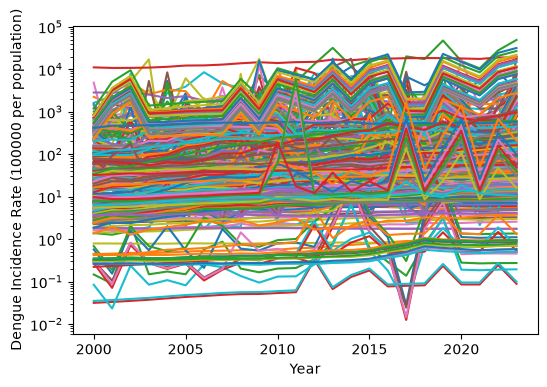

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
for location_id in AA.location_id.unique():
    df = AA[AA.location_id == location_id]
    ax.plot(df.year_id, df.dengue_inc_rate * RATE_PER, label=LOCATION_NAME.get(location_id, "?"))
ax.set_xlabel("Year")
ax.set_ylabel(f"Dengue Incidence Rate ({RATE_PER} per population)")
# Set y to log scale to see the small rates better
ax.set_yscale("log")

## Define your location set here

Anything in the FHS hierarchy: `1` global, level-1 super-regions, level-2 regions,
countries, subnationals.

In [11]:
location_id_set = [1, 4, 31, 64, 103, 137, 158, 166]   # global + all 7 super-regions

describe(location_id_set)

,location_id,location_name,level,n_fhs_leaves
0,1,Global,0,473
1,4,"Southeast Asia, East Asia, and Oceania",1,99
2,31,"Central Europe, Eastern Europe, and Central Asia",1,29
3,64,High-income,1,99
4,103,Latin America and Caribbean,1,90
5,137,North Africa and Middle East,1,21
6,158,South Asia,1,41
7,166,Sub-Saharan Africa,1,94


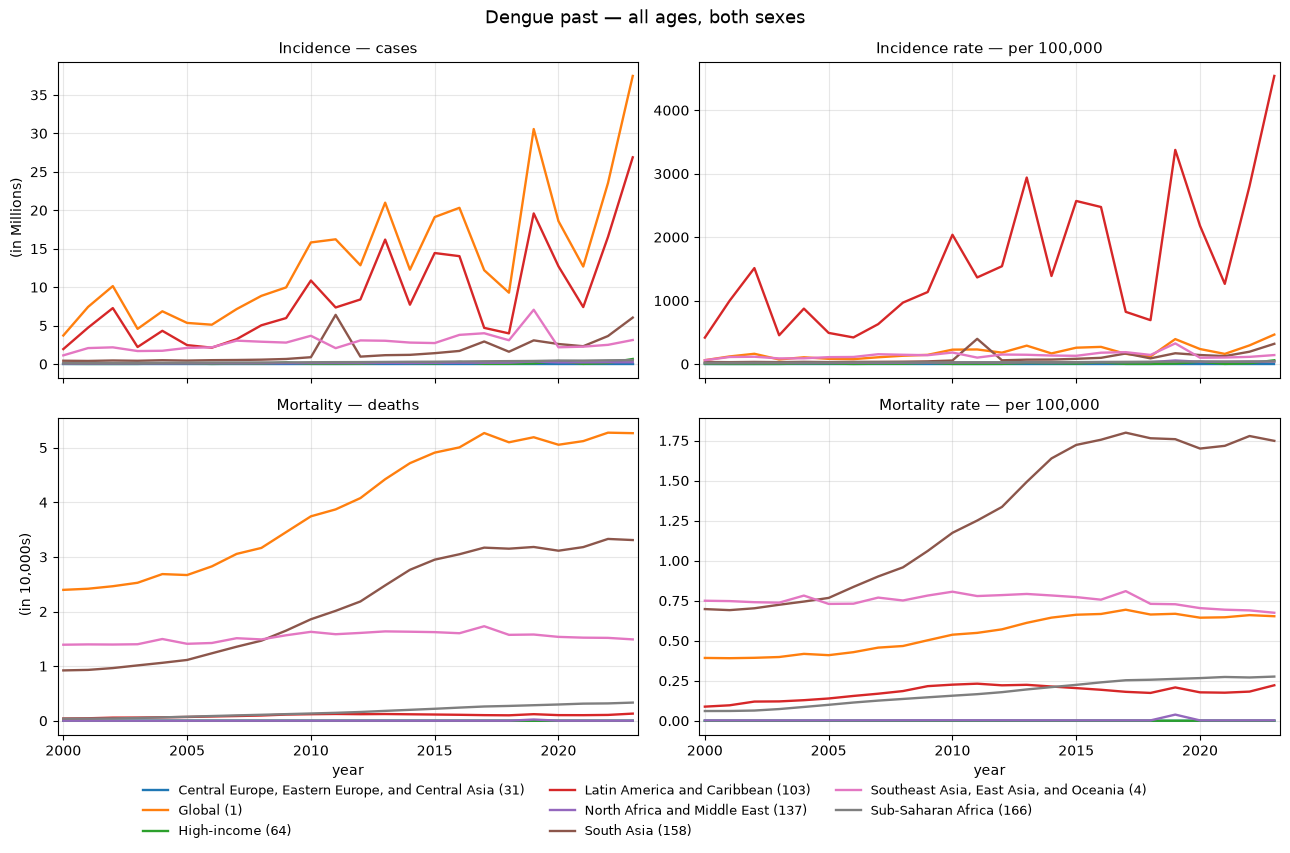

In [12]:
fig, _ = plot_outcomes(location_id_set)

## Countries

In [13]:
countries = [6, 11, 15, 20, 135, 163, 214]  # China, Indonesia, Myanmar, Viet Nam, Brazil, India, Nigeria
describe(countries)

,location_id,location_name,level,n_fhs_leaves
0,6,China,3,33
1,11,Indonesia,3,34
2,15,Myanmar,3,1
3,20,Viet Nam,3,1
4,135,Brazil,3,27
5,163,India,3,31
6,214,Nigeria,3,37


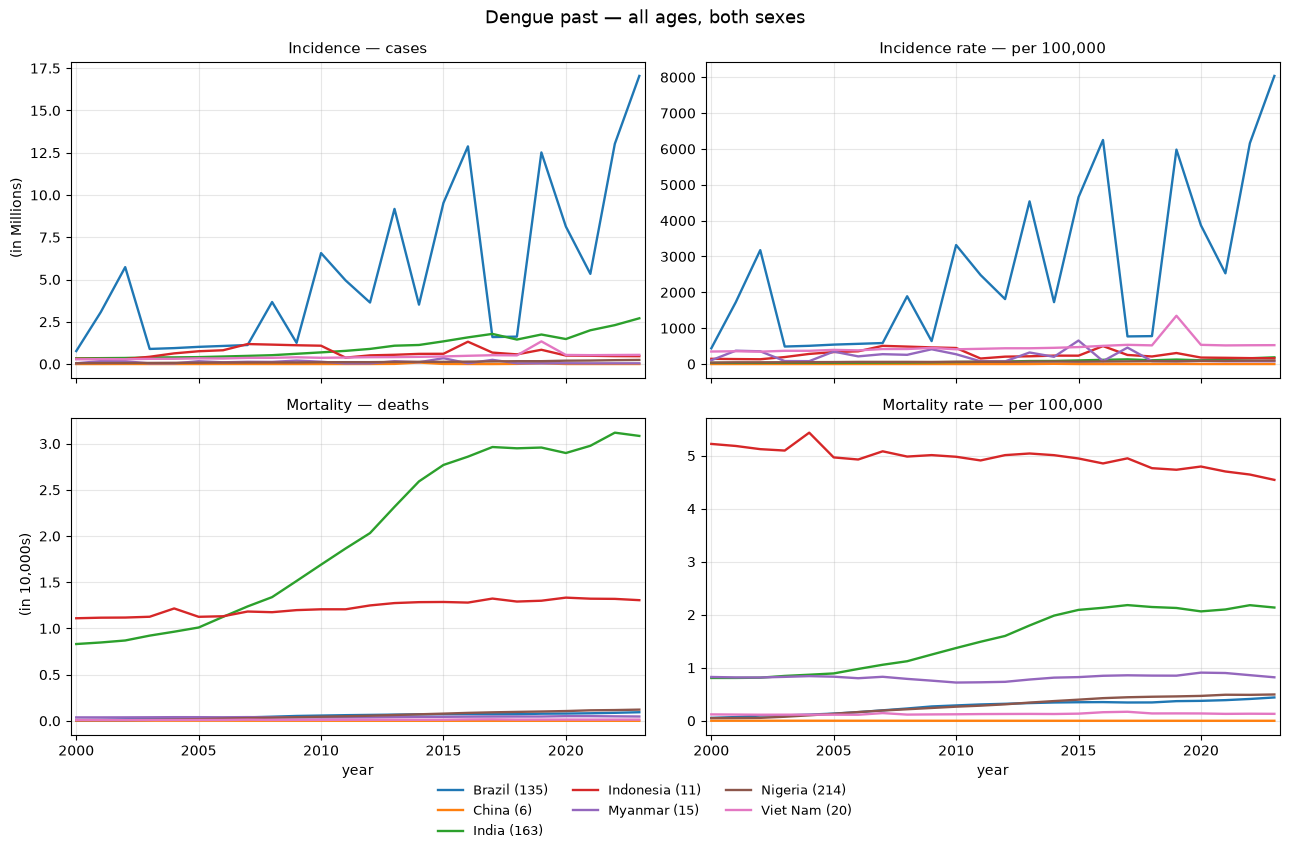

In [14]:
fig, _ = plot_outcomes(countries)

## Age/sex-specific

Name `age_group_ids` and/or `sex_ids` to get specific cells — one line per
(location, age, sex). Rates here are divided by that cell's own population at that
level, not by the location's all-age population.

,location_id,year_id,age_group_id,sex_id,dengue_inc_count,dengue_mort_count,population,dengue_inc_rate,dengue_mort_rate,series
457230,135,2000,11,2,29728.516324,2.330880,6.892855e+06,0.004313,3.381589e-07,Brazil · age 11 · sex 2
457330,135,2001,11,2,117354.694528,2.995622,6.938117e+06,0.016914,4.317630e-07,Brazil · age 11 · sex 2
457430,135,2002,11,2,217696.179460,4.151802,6.998274e+06,0.031107,5.932609e-07,Brazil · age 11 · sex 2
457530,135,2003,11,2,34047.045866,4.477589,7.068974e+06,0.004816,6.334143e-07,Brazil · age 11 · sex 2
457630,135,2004,11,2,36015.509998,5.228028,7.155522e+06,0.005033,7.306285e-07,Brazil · age 11 · sex 2


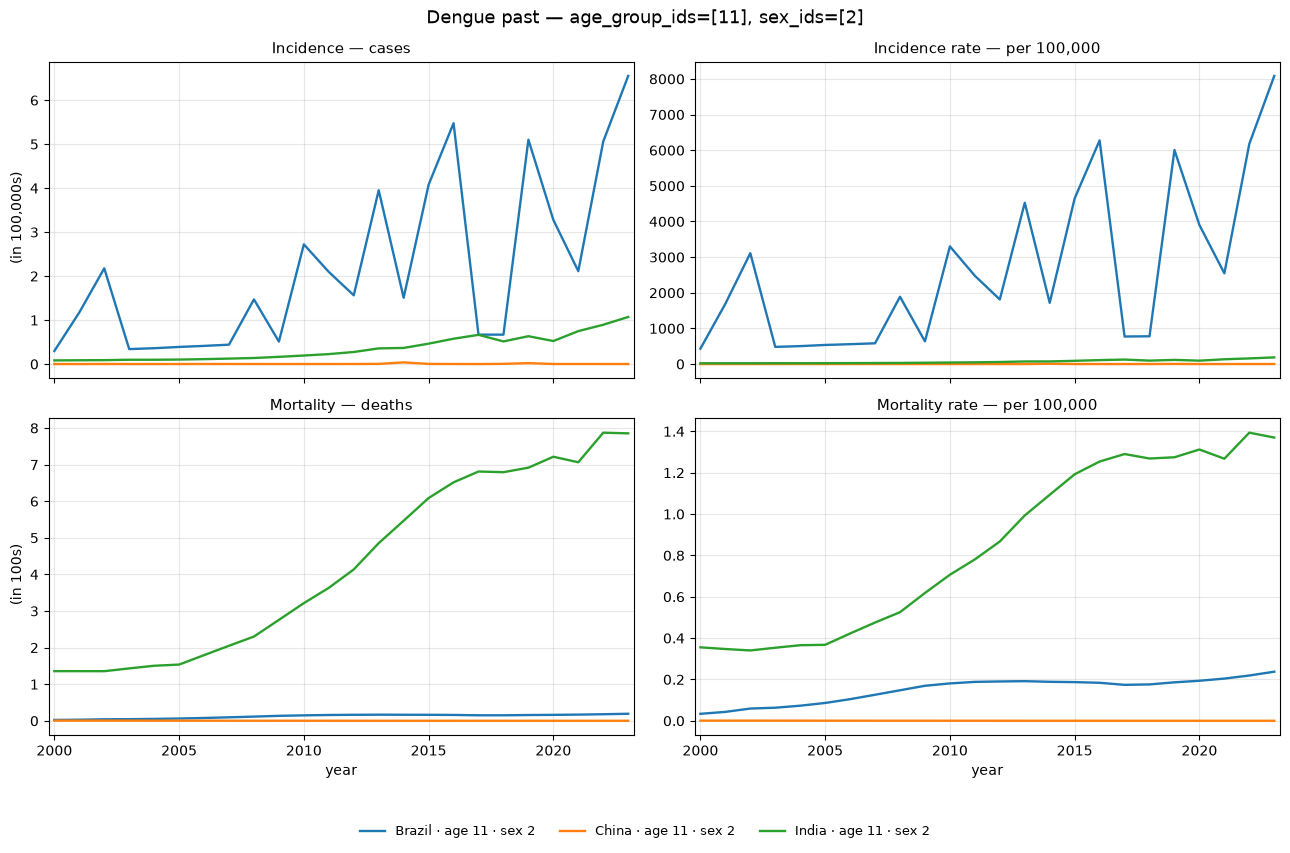

In [9]:
# rate for one age group and one sex, in a few locations
fig, cell_df = plot_outcomes([6, 135, 163], age_group_ids=[11], sex_ids=[2])
cell_df.head()

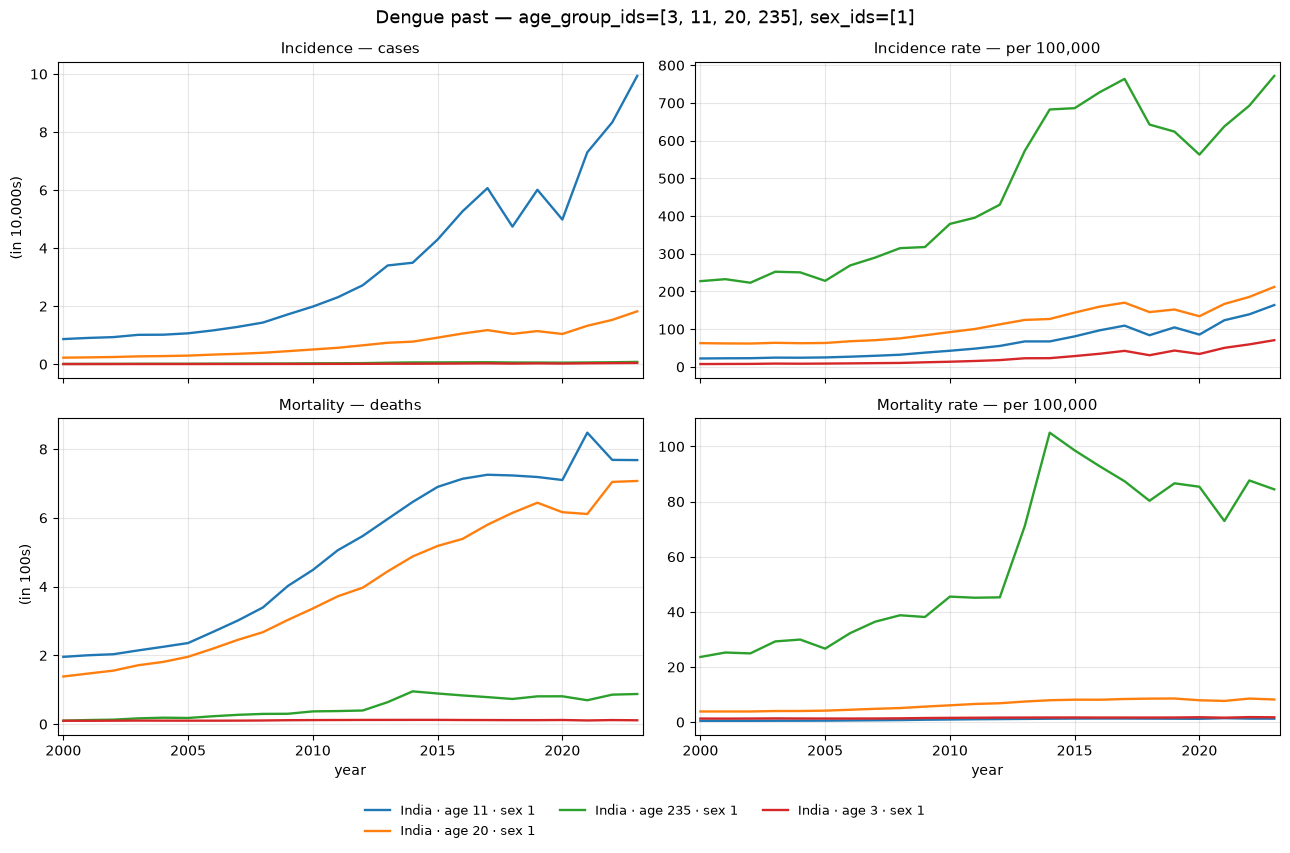

In [10]:
# age pattern within one location: several age groups, both sexes pooled? no --
# each (age, sex) is its own line, so pick the sexes you want explicitly
fig, _ = plot_outcomes([163], age_group_ids=[3, 11, 20, 235], sex_ids=[1])

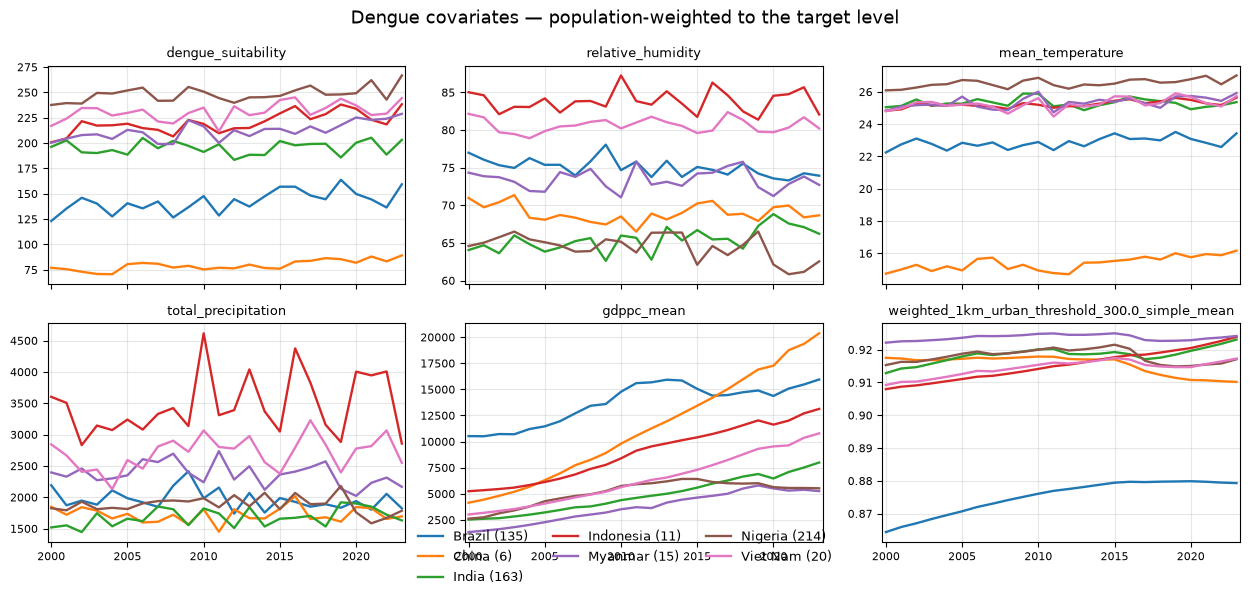

In [11]:
fig, _ = plot_covariates(
    countries,
    ["dengue_suitability", "relative_humidity", "mean_temperature",
     "total_precipitation", "gdppc_mean", "weighted_1km_urban_threshold_300.0_simple_mean"],
)

## Sanity checks

An aggregate that doesn't reproduce its own leaves is the failure mode that looks
completely plausible on a plot.

In [12]:
# 1. Counts: global must equal the direct sum over all 473 leaves.
direct = (leaves.groupby("year_id", as_index=False)
          .agg(inc=("dengue_inc_count", "sum"), mort=("dengue_mort_count", "sum")))
g = AA[AA.location_id == 1].sort_values("year_id")
assert np.allclose(g["dengue_inc_count"].to_numpy(), direct["inc"].to_numpy())
assert np.allclose(g["dengue_mort_count"].to_numpy(), direct["mort"].to_numpy())
print("global counts == sum of leaves: OK")

# 2. Age/sex counts must sum back to the all-age counts, for every node and year.
rebuilt = (AS.groupby(["location_id", "year_id"], as_index=False)
           .agg(inc=("dengue_inc_count", "sum")))
chk = AA.merge(rebuilt, on=["location_id", "year_id"])
assert np.allclose(chk["dengue_inc_count"], chk["inc"])
print(f"age/sex counts sum to all-age across {chk.location_id.nunique()} nodes: OK")

# 3. Age/sex population must sum to the all-age population it was divided by.
pop_chk = (AS.groupby(["location_id", "year_id"], as_index=False)
           .agg(as_pop=("population", "sum"))
           .merge(AA[["location_id", "year_id", "population"]], on=["location_id", "year_id"]))
worst = (pop_chk.as_pop / pop_chk.population - 1).abs().max()
print(f"max |as_pop/aa_pop - 1| across all nodes: {worst:.2e}")

# 4. The denominator rule, made visible: own population vs summed-children.
leaf_pop_sum = (leaves.groupby("year_id", as_index=False)
                .agg(leaf_pop=("population", "sum")))
cmp = g.merge(leaf_pop_sum, on="year_id")
cmp["rate_own"] = cmp.dengue_inc_count / cmp.population
cmp["rate_summed_children"] = cmp.dengue_inc_count / cmp.leaf_pop
cmp["pct_inflation"] = 100 * (cmp.rate_summed_children / cmp.rate_own - 1)
print("\nGlobal incidence rate, own population vs summed-children denominator:")
print(cmp[["year_id", "rate_own", "rate_summed_children", "pct_inflation"]]
      .tail(3).to_string(index=False))

global counts == sum of leaves: OK
age/sex counts sum to all-age across 513 nodes: OK
max |as_pop/aa_pop - 1| across all nodes: 4.44e-16

Global incidence rate, own population vs summed-children denominator:
 year_id  rate_own  rate_summed_children  pct_inflation
    2021  0.001601              0.001602       0.078358
    2022  0.002944              0.002947       0.077465
    2023  0.004645              0.004649       0.076876
